In [4]:
import librosa
import torch
import matplotlib.pyplot as plt
import numpy as np

def create_spectrogram_plot(ax, audio_np, onset_times, sr, fmax=8000,
                           show_xlabel=True, show_ylabel=True, ylabel_text=None):
    M = librosa.feature.melspectrogram(y=audio_np, sr=sr, n_mels=128, fmax=fmax)
    M_db = librosa.power_to_db(M, ref=np.max)

    librosa.display.specshow(M_db, x_axis='time', y_axis='mel', ax=ax, sr=sr, fmax=fmax)

    # Add onset lines
    for t in onset_times:
        ax.axvline(x=t, color='cyan', linestyle='--', alpha=0.9, linewidth=2)

    # Convert y-axis to normalized frequency
    yticks_hz = np.array(ax.get_yticks())
    yticks_normalized = (yticks_hz / (sr/2)) * np.pi

    if show_ylabel:
        ax.set_ylabel('Normalized Frequency (rad)')
        ax.set_yticks(yticks_hz)
        ax.set_yticklabels([f'{val:.2f}' if val <= np.pi/4 else '' for val in yticks_normalized])

        # Add rotated label on the right side
        if ylabel_text:
            ax.text(1.02, 0.5, ylabel_text, transform=ax.transAxes,
                   rotation=270, va='center', fontsize=12, fontweight='bold')
    else:
        ax.set_ylabel('')
        ax.set_yticks(yticks_hz)
        ax.set_yticklabels([])

    if show_xlabel:
        ax.set_xlabel('Time (s)')
    else:
        ax.set_xlabel('')

    return ax

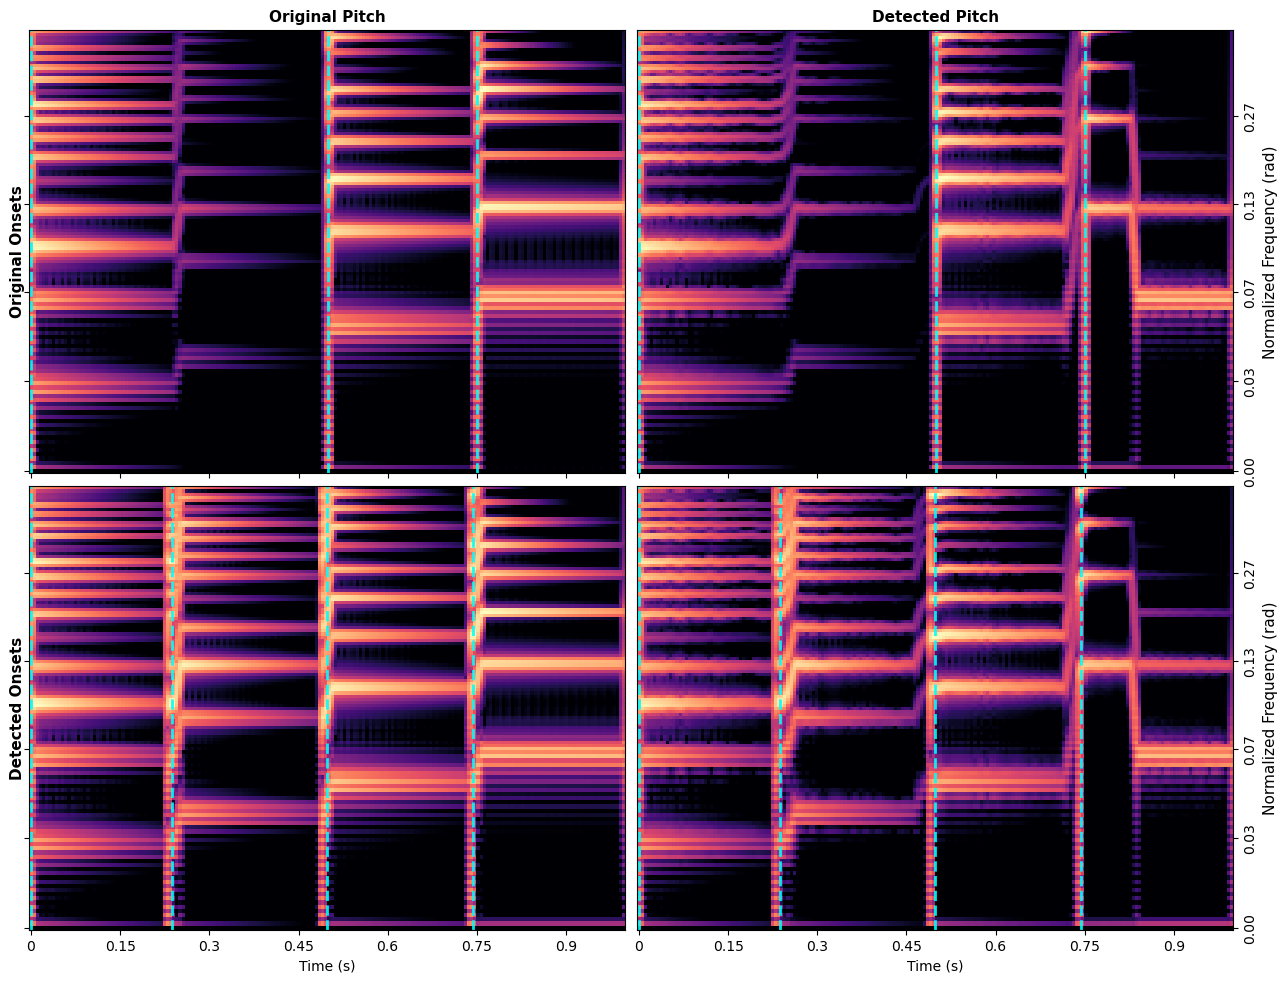

Real onset positions: [0, 50, 75]
Detected onset times: [0.         0.23733333 0.49866667 0.744     ]


In [7]:
from synths.synth import Synth, SynthConfig
from synths.utils import detect_onsets, detect_f0

FS = 96000
DURATION = 1.0
NUM_FRAMES = 100

# Fixed parameter ranges (matching widget defaults)
f0_min, f0_max = 490.0, 1000.0
pluck_min, pluck_max = 0.8, 0.9
burst_min, burst_max = 0.8, 0.8
dynamic_min, dynamic_max = 0.5, 1.0
a1_min, a1_max = 0.1, 0.25
decay_min, decay_max = 0.97, 1.0

n_onsets = 4
onset_spacing_frames = 25

sized_t = torch.ones(1, NUM_FRAMES)

params_og = {
    "onset_probs": sized_t * 0.0,
    "f0": sized_t * f0_min,
    "pluck_position": sized_t * pluck_min,
    "burst_gain": sized_t * burst_min,
    "dynamic_level": sized_t * dynamic_min,
    "a1": sized_t * a1_min,
    "decay": sized_t * decay_min,
}

# Define onset positions
onset_positions = [0, 25, 50, 75]
real_onset_positions = [0, 50, 75]  # Skip position 25
params_og["onset_probs"][0, real_onset_positions] = 1.0

# Interpolate parameters
for i in range(len(onset_positions)):
    start_frame = onset_positions[i]
    end_frame = onset_positions[i+1] if i+1 < len(onset_positions) else NUM_FRAMES
    t = i / max(1, n_onsets - 1)

    params_og["f0"][0, start_frame:end_frame] = f0_min * (1 - t) + f0_max * t
    params_og["pluck_position"][0, start_frame:end_frame] = pluck_min * (1 - t) + pluck_max * t
    params_og["burst_gain"][0, start_frame:end_frame] = burst_min * (1 - t) + burst_max * t
    params_og["dynamic_level"][0, start_frame:end_frame] = dynamic_min * (1 - t) + dynamic_max * t
    params_og["a1"][0, start_frame:end_frame] = a1_min * (1 - t) + a1_max * t
    params_og["decay"][0, start_frame:end_frame] = decay_min * (1 - t) + decay_max * t

# Synthesize original
num_samples = int(DURATION * FS)
synth = Synth(SynthConfig(num_samples=num_samples, fs=FS))
x_og = synth.oracle_synth(params_og)
x_og_np = x_og.squeeze().cpu().numpy()

# Detect f0 and onsets
f0_detected_np, conf_np, times_crepe = detect_f0(x_og, sr=FS)
onset_times_detected = detect_onsets(x_og_np, sr=FS)

# Convert detections to frame format
detected_onset_frames = (onset_times_detected / DURATION * NUM_FRAMES).astype(int)
detected_onset_frames = np.clip(detected_onset_frames, 0, NUM_FRAMES - 1)
onset_probs_detected = torch.zeros(1, NUM_FRAMES)
if len(detected_onset_frames) > 0:
    onset_probs_detected[0, detected_onset_frames] = 1.0

f0_detected_resampled = torch.from_numpy(
    np.interp(
        np.linspace(0, 1, NUM_FRAMES),
        np.linspace(0, 1, len(f0_detected_np)),
        f0_detected_np
    )
).unsqueeze(0)

# Original onset times for plotting
og_onset_times = np.where(params_og['onset_probs'].squeeze() > 0)[0] / NUM_FRAMES * DURATION

# === CREATE 4 VERSIONS ===
# 1. Original onsets + Original f0
x_og_onsets_og_f0 = x_og_np

# 2. Original onsets + Detected f0
params_og_onsets_detected_f0 = params_og.copy()
params_og_onsets_detected_f0["f0"] = f0_detected_resampled
x_og_onsets_detected_f0 = synth.oracle_synth(params_og_onsets_detected_f0)
x_og_onsets_detected_f0_np = x_og_onsets_detected_f0.squeeze().cpu().numpy()

# 3. Detected onsets + Original f0
params_detected_onsets_og_f0 = params_og.copy()
params_detected_onsets_og_f0["onset_probs"] = onset_probs_detected
x_detected_onsets_og_f0 = synth.oracle_synth(params_detected_onsets_og_f0)
x_detected_onsets_og_f0_np = x_detected_onsets_og_f0.squeeze().cpu().numpy()

# 4. Detected onsets + Detected f0
params_detected_onsets_detected_f0 = params_og.copy()
params_detected_onsets_detected_f0["onset_probs"] = onset_probs_detected
params_detected_onsets_detected_f0["f0"] = f0_detected_resampled
x_detected_onsets_detected_f0 = synth.oracle_synth(params_detected_onsets_detected_f0)
x_detected_onsets_detected_f0_np = x_detected_onsets_detected_f0.squeeze().cpu().numpy()

# === PLOT 2x2 GRID ===
HSPACE = 0.03
WSPACE = 0.02

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                        gridspec_kw={'hspace': HSPACE, 'wspace': WSPACE})

# Helper function to move y-axis to right
def move_yaxis_to_right(ax, show_labels=True):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    if show_labels:
        for label in ax.get_yticklabels():
            label.set_rotation(90)
            label.set_verticalalignment('center')

# Top left: Original onsets + Original f0
create_spectrogram_plot(axes[0, 0], x_og_onsets_og_f0, og_onset_times,
                        FS, show_xlabel=False, show_ylabel=False)
axes[0, 0].set_xticklabels([])
axes[0, 0].set_ylabel('Original Onsets', fontsize=11, fontweight='bold', rotation=90, va='center')
axes[0, 0].yaxis.set_label_coords(-0.02, 0.5)
axes[0, 0].set_title('Original Pitch', fontsize=11, fontweight='bold')

# Top right: Original onsets + Detected f0
create_spectrogram_plot(axes[0, 1], x_og_onsets_detected_f0_np, og_onset_times,
                        FS, show_xlabel=False, show_ylabel=True)
axes[0, 1].set_xticklabels([])
move_yaxis_to_right(axes[0, 1], show_labels=True)
axes[0, 1].set_ylabel('Normalized Frequency (rad)', fontsize=11)
axes[0, 1].set_title('Detected Pitch', fontsize=11, fontweight='bold')

# Bottom left: Detected onsets + Original f0
create_spectrogram_plot(axes[1, 0], x_detected_onsets_og_f0_np, onset_times_detected,
                       FS, show_xlabel=True, show_ylabel=False)
axes[1, 0].set_ylabel('Detected Onsets', fontsize=11, fontweight='bold', rotation=90, va='center')
axes[1, 0].yaxis.set_label_coords(-0.02, 0.5)

# Bottom right: Detected onsets + Detected f0
create_spectrogram_plot(axes[1, 1], x_detected_onsets_detected_f0_np, onset_times_detected,
                       FS, show_xlabel=True, show_ylabel=True)
move_yaxis_to_right(axes[1, 1], show_labels=True)
axes[1, 1].set_ylabel('Normalized Frequency (rad)', fontsize=11)

plt.subplots_adjust(left=0.06, right=0.92, top=0.96, bottom=0.06,
                   hspace=HSPACE, wspace=WSPACE)
plt.show()

# Store for later use
exp2_results = {
    'x_og_onsets_og_f0': x_og_onsets_og_f0,
    'x_og_onsets_detected_f0': x_og_onsets_detected_f0_np,
    'x_detected_onsets_og_f0': x_detected_onsets_og_f0_np,
    'x_detected_onsets_detected_f0': x_detected_onsets_detected_f0_np,
    'og_onset_times': og_onset_times,
    'detected_onset_times': onset_times_detected
}

print(f"Real onset positions: {real_onset_positions}")
print(f"Detected onset times: {onset_times_detected}")

In [8]:
from IPython.display import Audio, display

print("=" * 60)
print("AUDIO PLAYBACK")
print("=" * 60)

print("\n1. Original Onsets + Original f0:")
display(Audio(exp2_results['x_og_onsets_og_f0'], rate=FS))

print("\n2. Original Onsets + Detected f0:")
display(Audio(exp2_results['x_og_onsets_detected_f0'], rate=FS))

print("\n3. Detected Onsets + Original f0:")
display(Audio(exp2_results['x_detected_onsets_og_f0'], rate=FS))

print("\n4. Detected Onsets + Detected f0:")
display(Audio(exp2_results['x_detected_onsets_detected_f0'], rate=FS))

AUDIO PLAYBACK

1. Original Onsets + Original f0:



2. Original Onsets + Detected f0:



3. Detected Onsets + Original f0:



4. Detected Onsets + Detected f0:
